# Phase 5 ? Transfer Learning (MobileNetV2)

**Goal:** Use a pre-trained MobileNetV2 backbone (ImageNet weights) to classify the 4-class blood-cell dataset.  
Two-stage protocol: (1) train only the classification head with the base frozen, then (2) unfreeze the top layers for fine-tuning.

In [5]:
import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from pathlib import Path
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

print('TF version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)

TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# -- Paths ------------------------------------------------------------------
BASE_DIR   = Path('/mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML')
DATA_DIR   = Path.home() / 'blood_cell_data'   # cached dataset in WSL home
TRAIN_DIR  = DATA_DIR / 'TRAIN'
TEST_DIR   = DATA_DIR / 'TEST'
MODELS_DIR = BASE_DIR / 'models';  MODELS_DIR.mkdir(exist_ok=True)
FIGS_DIR   = BASE_DIR / 'outputs' / 'figures';  FIGS_DIR.mkdir(parents=True, exist_ok=True)

# -- Input configuration -----------------------------------------------------
IMG_SIZE    = (224, 224)       # MobileNetV2 native resolution
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2              # fraction of TRAIN used for validation
SEED        = 42

# Auto-detect class names from TRAIN folder structure
import os
CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(TRAIN_DIR / d) and not d.startswith('.')
])
NUM_CLASSES = len(CLASSES)
print('Classes detected:', CLASSES)

# -- Reference scores from previous phases -----------------------------------
PHASE2_TEST_ACC = 0.6998   # best custom CNN   (Phase 2)
PHASE3_TEST_ACC = 0.7238   # best improved CNN (Phase 3)

print('Data dir  :', DATA_DIR)
print('IMG_SIZE  :', IMG_SIZE)
for split_name, split_dir in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    n = sum(
        len(list((split_dir / c).glob('*.jpg')) +
            list((split_dir / c).glob('*.png')) +
            list((split_dir / c).glob('*.jpeg')))
        for c in CLASSES
    )
    print(f'  {split_name}: {n} images')


Classes detected: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Data dir  : /home/arman/blood_cell_data
IMG_SIZE  : (224, 224)
  train: 9957 images
  test: 2487 images


## 1. Data Pipeline

MobileNetV2 requires its own preprocessing: pixel values are mapped from `[0, 255]` ? `[-1, 1]`  
via `mobilenet_v2.preprocess_input`.  **Do NOT use simple `/255` normalization** ? that degrades  
performance because the ImageNet weights were learned with a different input distribution.

In [7]:
def preprocess_fn(image, label):
    """Cast to float32 then apply MobileNetV2 preprocessing  [0,255] -> [-1,1]."""
    image = tf.cast(image, tf.float32)
    image = mobilenet_preprocess(image)
    return image, label

def build_datasets(img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                   val_split=VAL_SPLIT, seed=SEED):
    """Load train/val from TRAIN dir (val_split) + test from TEST dir."""
    base_kwargs = dict(
        labels='inferred',
        label_mode='categorical',
        class_names=CLASSES,
        image_size=img_size,
        batch_size=batch_size,
        validation_split=val_split,
        seed=seed
    )

    ds_train = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, subset='training', shuffle=True, **base_kwargs
    ).map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    ds_val = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, subset='validation', shuffle=False, **base_kwargs
    ).map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    ds_test = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASSES,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False,
        seed=seed
    ).map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE
    ).prefetch(tf.data.AUTOTUNE)

    return ds_train, ds_val, ds_test

ds_train, ds_val, ds_test = build_datasets()
print('Datasets ready.')
print('Train batches:', len(ds_train))
print('Val   batches:', len(ds_val))
print('Test  batches:', len(ds_test))


Found 9957 files belonging to 4 classes.
Using 7966 files for training.


I0000 00:00:1779907196.228111     104 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Datasets ready.
Train batches: 249
Val   batches: 63
Test  batches: 78


## 2. Model Architecture

### Design choices

| Choice | Reason |
|--------|--------|
| `GlobalAveragePooling2D` (not Flatten) | Fewer parameters; spatial invariance; less overfitting |
| `base_model(x, training=False)` | Keeps BatchNorm layers in inference mode ? uses running statistics, not batch statistics. Critical for stable fine-tuning. |
| Dropout before final Dense | Regularisation on the head |
| `include_top=False` | Removes ImageNet 1000-class head, keeps feature extractor |

In [8]:
def build_model(dropout_rate=0.3):
    """MobileNetV2 backbone + lightweight classification head."""
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   # frozen for Stage 1

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    # Pass training=False so BN uses running averages even during model.fit
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

# Quick sanity check
_m, _b = build_model()
_m.summary(line_length=90)
print(f'\nTotal params     : {_m.count_params():,}')
print(f'Trainable params : {sum(np.prod(v.shape) for v in _m.trainable_variables):,}')
del _m, _b

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d              │ (None, 1280)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 4)                    │           5,124 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total params     : 2,263,108
Trainable params : 5,124


## 3. Experiment Plan

| ID | Stage 1 dropout | Stage 2 unfreeze (top N layers) | Description |
|----|----------------|---------------------------------|-------------|
| exp1 | 0.3 | ? | Head-only, lighter regularisation |
| exp2 | 0.5 | ? | Head-only, stronger regularisation |
| exp3 | best S1 | top 30 layers | Fine-tune shallow top of backbone |
| exp4 | best S1 | top 50 layers | Fine-tune deeper portion of backbone |

**Stage 1 LR = 1e-3** (head warm-up)  
**Stage 2 LR = 1e-5** (gentle fine-tuning ? large LR would destroy pretrained weights)

In [9]:
histories = {}   # stores all history objects
models   = {}    # stores trained models keyed by name

def run_stage1(exp_name, dropout_rate, epochs=30, lr=1e-3):
    """Train classification head with MobileNetV2 base frozen."""
    print(f'\n{'='*60}')
    print(f'  {exp_name}  |  dropout={dropout_rate}  |  LR={lr}')
    print(f'{'='*60}')

    model, base_model = build_model(dropout_rate)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    ckpt_path = str(MODELS_DIR / f'{exp_name}_best.keras')
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

    hist = model.fit(
        ds_train, validation_data=ds_val,
        epochs=epochs, callbacks=callbacks, verbose=1
    )

    val_acc = max(hist.history['val_accuracy'])
    print(f'\n  >> Best val_accuracy: {val_acc:.4f}')

    histories[exp_name] = hist.history
    models[exp_name]    = model
    return model, base_model

## 4. Stage 1 ? Head Training (Base Frozen)

In [10]:
model_s1_drop03, base_drop03 = run_stage1('exp1_s1_drop03', dropout_rate=0.3)


  exp1_s1_drop03  |  dropout=0.3  |  LR=0.001
Epoch 1/30


I0000 00:00:1779907231.508997     299 service.cc:153] XLA service 0x7c3f2406e060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779907231.509039     299 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779907231.707838     299 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779907232.368828     299 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779907232.422259     299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10141__.122
E0000 00:00:1779907234.395354     299 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/249 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.3872 - loss: 1.9530  

I0000 00:00:1779907240.967491     299 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4069 - loss: 1.3985

I0000 00:00:1779907247.018476     298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10141__.122
E0000 00:00:1779907248.748290     298 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4080 - loss: 1.3958

E0000 00:00:1779907261.412208     298 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


249/249 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.5023 - loss: 1.1681 - val_accuracy: 0.7715 - val_loss: 0.6952 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6575 - loss: 0.8410 - val_accuracy: 0.6293 - val_loss: 0.9154 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7123 - loss: 0.7277 - val_accuracy: 0.8388 - val_loss: 0.5173 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7315 - loss: 0.6760 - val_accuracy: 0.6148 - val_loss: 0.9202 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7470 - loss: 0.6481 - val_accuracy: 0.8262 - val_loss: 0.5415 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7577 - loss: 0.6142 - val_accuracy: 0.8523 - val_loss: 0.4726 - learning_rate: 0.0010
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7624 - loss: 0.6039 - v

In [11]:
model_s1_drop05, base_drop05 = run_stage1('exp2_s1_drop05', dropout_rate=0.5)


  exp2_s1_drop05  |  dropout=0.5  |  LR=0.001
Epoch 1/30


I0000 00:00:1779907402.870107     300 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45812__.122


247/249 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3693 - loss: 1.5539

I0000 00:00:1779907410.623426     297 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45812__.122


249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.4469 - loss: 1.3168 - val_accuracy: 0.6891 - val_loss: 0.8428 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6175 - loss: 0.9318 - val_accuracy: 0.7192 - val_loss: 0.7839 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6500 - loss: 0.8410 - val_accuracy: 0.6941 - val_loss: 0.7977 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6766 - loss: 0.7971 - val_accuracy: 0.7715 - val_loss: 0.6533 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.6853 - loss: 0.7692 - val_accuracy: 0.7825 - val_loss: 0.6469 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6957 - loss: 0.7542 - val_accuracy: 0.8182 - val_loss: 0.5467 - learning_rate: 0.0010
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6924 - loss: 0.7438 - va

## 5. Stage 2 ? Fine-Tuning (Top Layers Unfrozen)

We pick the **best Stage-1 model** and unfreeze only the top N layers of the backbone.  
The learning rate is reduced to **1e-5** to avoid destroying pretrained weights.

In [12]:
def run_finetune(exp_name, base_model, model, unfreeze_top_n, epochs=20, lr=1e-5):
    """Unfreeze top N backbone layers and continue training."""
    print(f'\n{'='*60}')
    print(f'  {exp_name}  |  unfreeze_top={unfreeze_top_n}  |  LR={lr}')
    print(f'{'='*60}')

    # Unfreeze top N layers of backbone
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_top_n]:
        layer.trainable = False

    trainable_count = sum(np.prod(v.shape) for v in model.trainable_variables)
    print(f'  Trainable params after unfreeze: {trainable_count:,}')

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    ckpt_path = str(MODELS_DIR / f'{exp_name}_best.keras')
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

    hist = model.fit(
        ds_train, validation_data=ds_val,
        epochs=epochs, callbacks=callbacks, verbose=1
    )

    val_acc = max(hist.history['val_accuracy'])
    print(f'\n  >> Best val_accuracy: {val_acc:.4f}')

    histories[exp_name] = hist.history
    models[exp_name]    = model
    return model

In [13]:
# Best Stage-1 model selection
s1_names = ['exp1_s1_drop03', 'exp2_s1_drop05']
best_s1_name = max(s1_names, key=lambda n: max(histories[n]['val_accuracy']))
print(f'Best Stage-1 model: {best_s1_name}')

# Use dropout=0.3 base for fine-tuning (we'll rebuild from best S1 weights)
model_ft = models[best_s1_name]
# Identify the base model layer
base_ft = [l for l in model_ft.layers if 'mobilenetv2' in l.name][0]

# exp3: fine-tune top 30 layers
import copy
# Rebuild to get a fresh copy at best S1 weights for exp3
model_exp3 = keras.models.clone_model(model_ft)
model_exp3.set_weights(model_ft.get_weights())
base_exp3 = [l for l in model_exp3.layers if 'mobilenetv2' in l.name][0]

model_exp3 = run_finetune('exp3_ft_top30', base_exp3, model_exp3, unfreeze_top_n=30)

Best Stage-1 model: exp1_s1_drop03

  exp3_ft_top30  |  unfreeze_top=30  |  LR=1e-05
  Trainable params after unfreeze: 1,531,524
Epoch 1/20


I0000 00:00:1779907586.051292     301 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88090__.166


246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4940 - loss: 2.0934

I0000 00:00:1779907597.741978     298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88090__.166


249/249 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.5910 - loss: 1.4305 - val_accuracy: 0.8729 - val_loss: 0.3508 - learning_rate: 1.0000e-05
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.7462 - loss: 0.6816 - val_accuracy: 0.8106 - val_loss: 0.4964 - learning_rate: 1.0000e-05
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8279 - loss: 0.4412 - val_accuracy: 0.8122 - val_loss: 0.5011 - learning_rate: 1.0000e-05
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8614 - loss: 0.3426 - val_accuracy: 0.8403 - val_loss: 0.4359 - learning_rate: 1.0000e-05
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8957 - loss: 0.2656 - val_accuracy: 0.8830 - val_loss: 0.3329 - learning_rate: 1.0000e-05
Epoch 6/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9192 - loss: 0.2012 - val_accuracy: 0.9051 - val_loss: 0.2678 - learning_rate: 1.0000e-05
Epoch 7/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0

In [14]:
# exp4: fine-tune top 50 layers ? rebuild from best S1 again
model_exp4 = keras.models.clone_model(model_ft)
model_exp4.set_weights(model_ft.get_weights())
base_exp4 = [l for l in model_exp4.layers if 'mobilenetv2' in l.name][0]

model_exp4 = run_finetune('exp4_ft_top50', base_exp4, model_exp4, unfreeze_top_n=50)


  exp4_ft_top50  |  unfreeze_top=50  |  LR=1e-05
  Trainable params after unfreeze: 1,860,228
Epoch 1/20


I0000 00:00:1779907827.127740     297 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_149981__.190


248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4863 - loss: 2.1384

I0000 00:00:1779907840.571049     298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_149981__.190


249/249 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.5901 - loss: 1.4346 - val_accuracy: 0.8925 - val_loss: 0.3134 - learning_rate: 1.0000e-05
Epoch 2/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7766 - loss: 0.5835 - val_accuracy: 0.8548 - val_loss: 0.4197 - learning_rate: 1.0000e-05
Epoch 3/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8536 - loss: 0.3781 - val_accuracy: 0.8483 - val_loss: 0.4194 - learning_rate: 1.0000e-05
Epoch 4/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8987 - loss: 0.2584 - val_accuracy: 0.8448 - val_loss: 0.4020 - learning_rate: 1.0000e-05
Epoch 5/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9239 - loss: 0.1958 - val_accuracy: 0.8820 - val_loss: 0.3113 - learning_rate: 1.0000e-05
Epoch 6/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9485 - loss: 0.1402 - val_accuracy: 0.9191 - val_loss: 0.2204 - learning_rate: 1.0000e-05
Epoch 7/20
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.

## 6. Training Results Summary

In [15]:
rows = []
for name, h in histories.items():
    stage = 'Stage 1' if 's1' in name else 'Stage 2'
    rows.append({
        'Experiment': name,
        'Stage': stage,
        'Best Val Acc': f"{max(h['val_accuracy']):.4f}",
        'Best Val Loss': f"{min(h['val_loss']):.4f}",
        'Epochs Run': len(h['accuracy'])
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

# Best Stage-1 and Stage-2 names for downstream use
s1_names = [n for n in histories if 's1' in n]
s2_names = [n for n in histories if 'ft' in n]
best_s1 = max(s1_names, key=lambda n: max(histories[n]['val_accuracy']))
best_s2 = max(s2_names, key=lambda n: max(histories[n]['val_accuracy']))
print(f'\nBest Stage-1: {best_s1}  ({max(histories[best_s1]["val_accuracy"]):.4f})')
print(f'Best Stage-2: {best_s2}  ({max(histories[best_s2]["val_accuracy"]):.4f})')

    Experiment   Stage Best Val Acc Best Val Loss  Epochs Run
exp1_s1_drop03 Stage 1       0.8885        0.3934          16
exp2_s1_drop05 Stage 1       0.8458        0.5271          15
 exp3_ft_top30 Stage 2       0.9895        0.0283          20
 exp4_ft_top50 Stage 2       0.9960        0.0193          20

Best Stage-1: exp1_s1_drop03  (0.8885)
Best Stage-2: exp4_ft_top50  (0.9960)


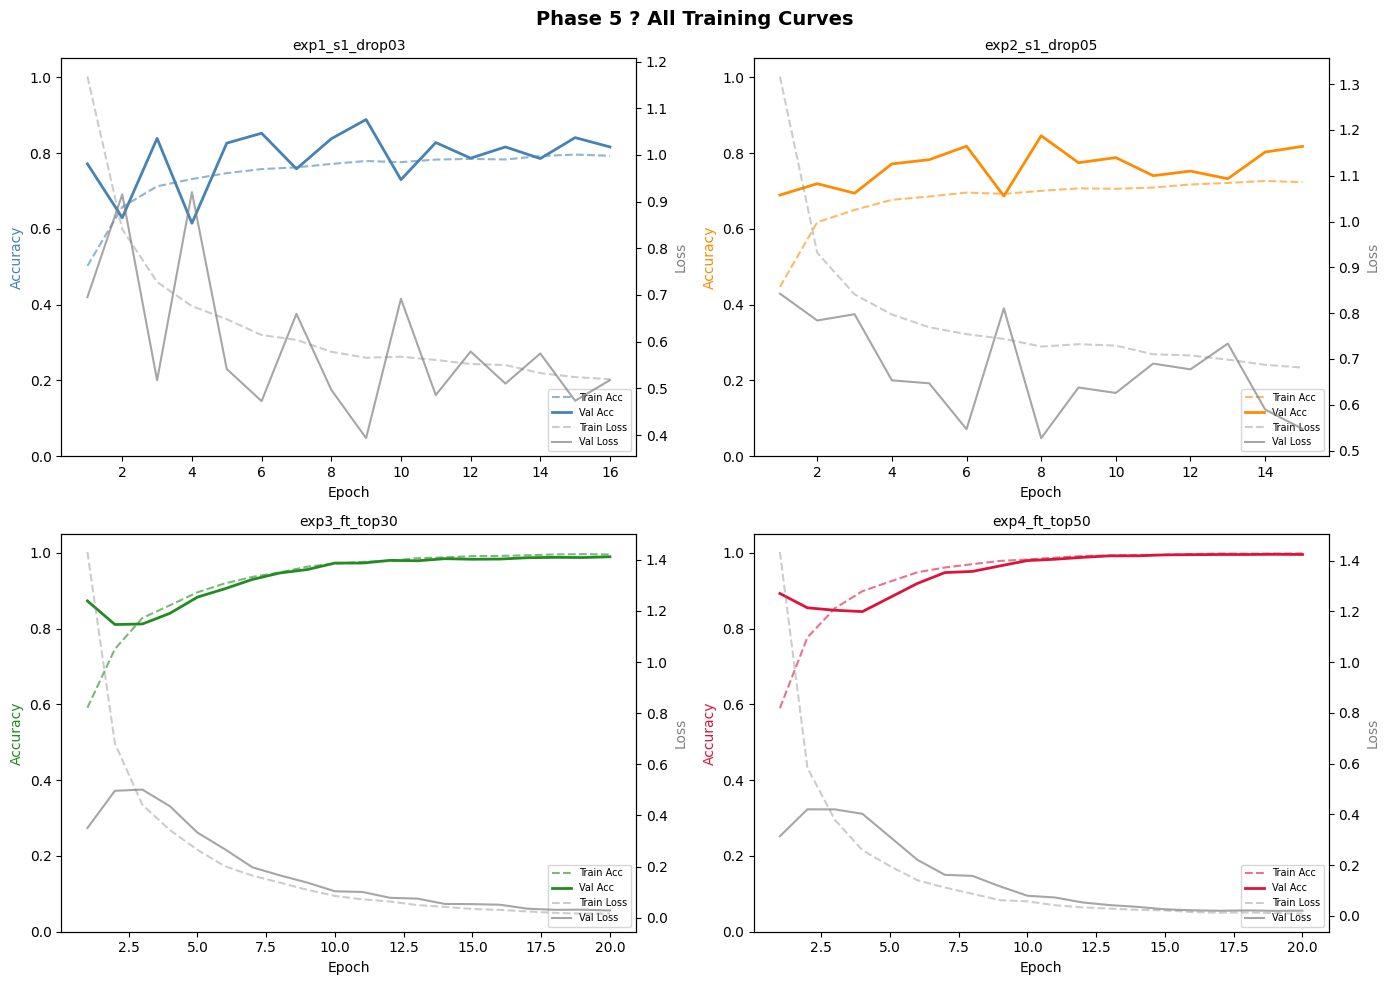

Saved: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/reports/figures/phase5_01_all_curves.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 5 ? All Training Curves', fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
exp_order = ['exp1_s1_drop03', 'exp2_s1_drop05', 'exp3_ft_top30', 'exp4_ft_top50']

for ax, exp_name, color in zip(axes.flat, exp_order, colors):
    if exp_name not in histories:
        ax.set_visible(False)
        continue
    h = histories[exp_name]
    ep = range(1, len(h['accuracy']) + 1)
    ax2 = ax.twinx()
    ax.plot(ep, h['accuracy'],     color=color,  ls='--', alpha=0.6, label='Train Acc')
    ax.plot(ep, h['val_accuracy'], color=color,  ls='-',  lw=2,      label='Val Acc')
    ax2.plot(ep, h['loss'],        color='gray', ls='--', alpha=0.4, label='Train Loss')
    ax2.plot(ep, h['val_loss'],    color='gray', ls='-',  alpha=0.7, label='Val Loss')
    ax.set_title(exp_name, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy', color=color)
    ax2.set_ylabel('Loss', color='gray')
    ax.set_ylim(0, 1.05)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='lower right')

plt.tight_layout()
save_path = FIGS_DIR / 'phase5_01_all_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path)

## 7. Test Set Evaluation

We evaluate both the best Stage-1 and best Stage-2 models on the held-out test split.

In [17]:
def evaluate_on_test(model, name):
    """Collect predictions and labels from the test set."""
    print(f'Evaluating {name} on test set...')
    loss, acc = model.evaluate(ds_test, verbose=0)
    print(f'  Test loss: {loss:.4f}  |  Test accuracy: {acc:.4f}')

    y_true_list, y_pred_list, y_prob_list = [], [], []
    for imgs, labels in ds_test:
        probs = model.predict(imgs, verbose=0)
        preds = np.argmax(probs, axis=1)
        trues = np.argmax(labels.numpy(), axis=1)
        y_true_list.append(trues)
        y_pred_list.append(preds)
        y_prob_list.append(probs)

    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    y_prob = np.concatenate(y_prob_list)
    return loss, acc, y_true, y_pred, y_prob

# ?? Stage 1 best ????????????????????????????????????????????????????????????
loss_s1, acc_s1, y_true_s1, y_pred_s1, y_prob_s1 = evaluate_on_test(models[best_s1], best_s1)

# ?? Stage 2 best ????????????????????????????????????????????????????????????
loss_s2, acc_s2, y_true_s2, y_pred_s2, y_prob_s2 = evaluate_on_test(models[best_s2], best_s2)

print(f'\nPhase 2 reference  : {PHASE2_TEST_ACC:.4f}')
print(f'Phase 3 reference  : {PHASE3_TEST_ACC:.4f}')
print(f'Phase 5 Stage 1    : {acc_s1:.4f}  (delta vs Ph3: {acc_s1-PHASE3_TEST_ACC:+.4f})')
print(f'Phase 5 Stage 2    : {acc_s2:.4f}  (delta vs Ph3: {acc_s2-PHASE3_TEST_ACC:+.4f})')

Evaluating exp1_s1_drop03 on test set...


E0000 00:00:1779908846.762351     301 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Test loss: 1.2246  |  Test accuracy: 0.5569
Evaluating exp4_ft_top50 on test set...
  Test loss: 1.1788  |  Test accuracy: 0.7467

Phase 2 reference  : 0.6998
Phase 3 reference  : 0.7238
Phase 5 Stage 1    : 0.5569  (delta vs Ph3: -0.1669)
Phase 5 Stage 2    : 0.7467  (delta vs Ph3: +0.0229)


In [18]:
print(f'\n--- Classification Report: {best_s2} (Stage 2 best) ---')
print(classification_report(y_true_s2, y_pred_s2, target_names=CLASSES))

print(f'\n--- Classification Report: {best_s1} (Stage 1 best) ---')
print(classification_report(y_true_s1, y_pred_s1, target_names=CLASSES))


--- Classification Report: exp4_ft_top50 (Stage 2 best) ---
              precision    recall  f1-score   support

  EOSINOPHIL       0.59      0.73      0.65       623
  LYMPHOCYTE       0.99      0.80      0.89       620
    MONOCYTE       0.97      0.59      0.73       620
  NEUTROPHIL       0.65      0.87      0.74       624

    accuracy                           0.75      2487
   macro avg       0.80      0.75      0.75      2487
weighted avg       0.80      0.75      0.75      2487


--- Classification Report: exp1_s1_drop03 (Stage 1 best) ---
              precision    recall  f1-score   support

  EOSINOPHIL       0.54      0.36      0.43       623
  LYMPHOCYTE       0.75      0.42      0.54       620
    MONOCYTE       0.65      0.64      0.64       620
  NEUTROPHIL       0.45      0.81      0.58       624

    accuracy                           0.56      2487
   macro avg       0.60      0.56      0.55      2487
weighted avg       0.60      0.56      0.55      2487



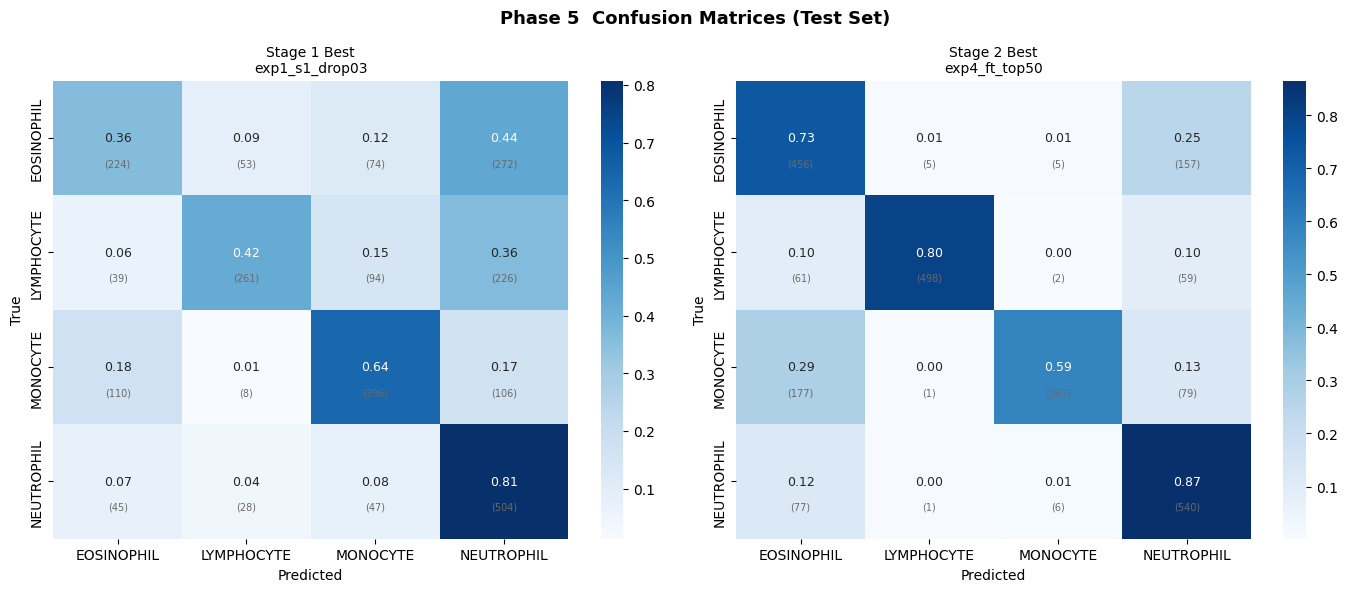

Saved: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/reports/figures/phase5_02_confusion_matrix.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 5  Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, (y_t, y_p, title) in zip(axes, [
    (y_true_s1, y_pred_s1, f'Stage 1 Best\n{best_s1}'),
    (y_true_s2, y_pred_s2, f'Stage 2 Best\n{best_s2}')
]):
    cm = confusion_matrix(y_t, y_p)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                annot_kws={'size': 9})
    # Overlay raw counts
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j+0.5, i+0.72, f'({cm[i,j]})',
                    ha='center', va='center', fontsize=7, color='dimgray')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
save_path = FIGS_DIR / 'phase5_02_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path)

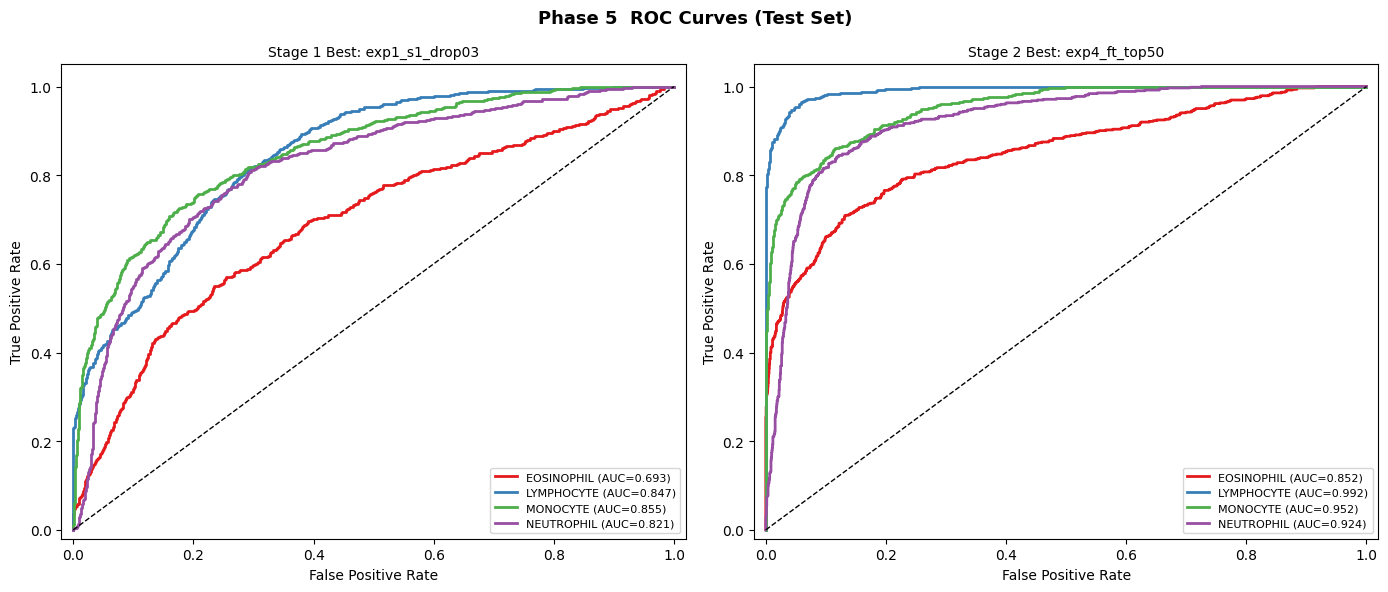

Saved: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/reports/figures/phase5_03_roc_curves.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 5  ROC Curves (Test Set)', fontsize=13, fontweight='bold')

palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for ax, (y_t, y_p_prob, title) in zip(axes, [
    (y_true_s1, y_prob_s1, f'Stage 1 Best: {best_s1}'),
    (y_true_s2, y_prob_s2, f'Stage 2 Best: {best_s2}')
]):
    y_t_bin = label_binarize(y_t, classes=list(range(NUM_CLASSES)))
    for i, (cls, col) in enumerate(zip(CLASSES, palette)):
        fpr, tpr, _ = roc_curve(y_t_bin[:, i], y_p_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
save_path = FIGS_DIR / 'phase5_03_roc_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path)

Found 2487 files belonging to 4 classes.


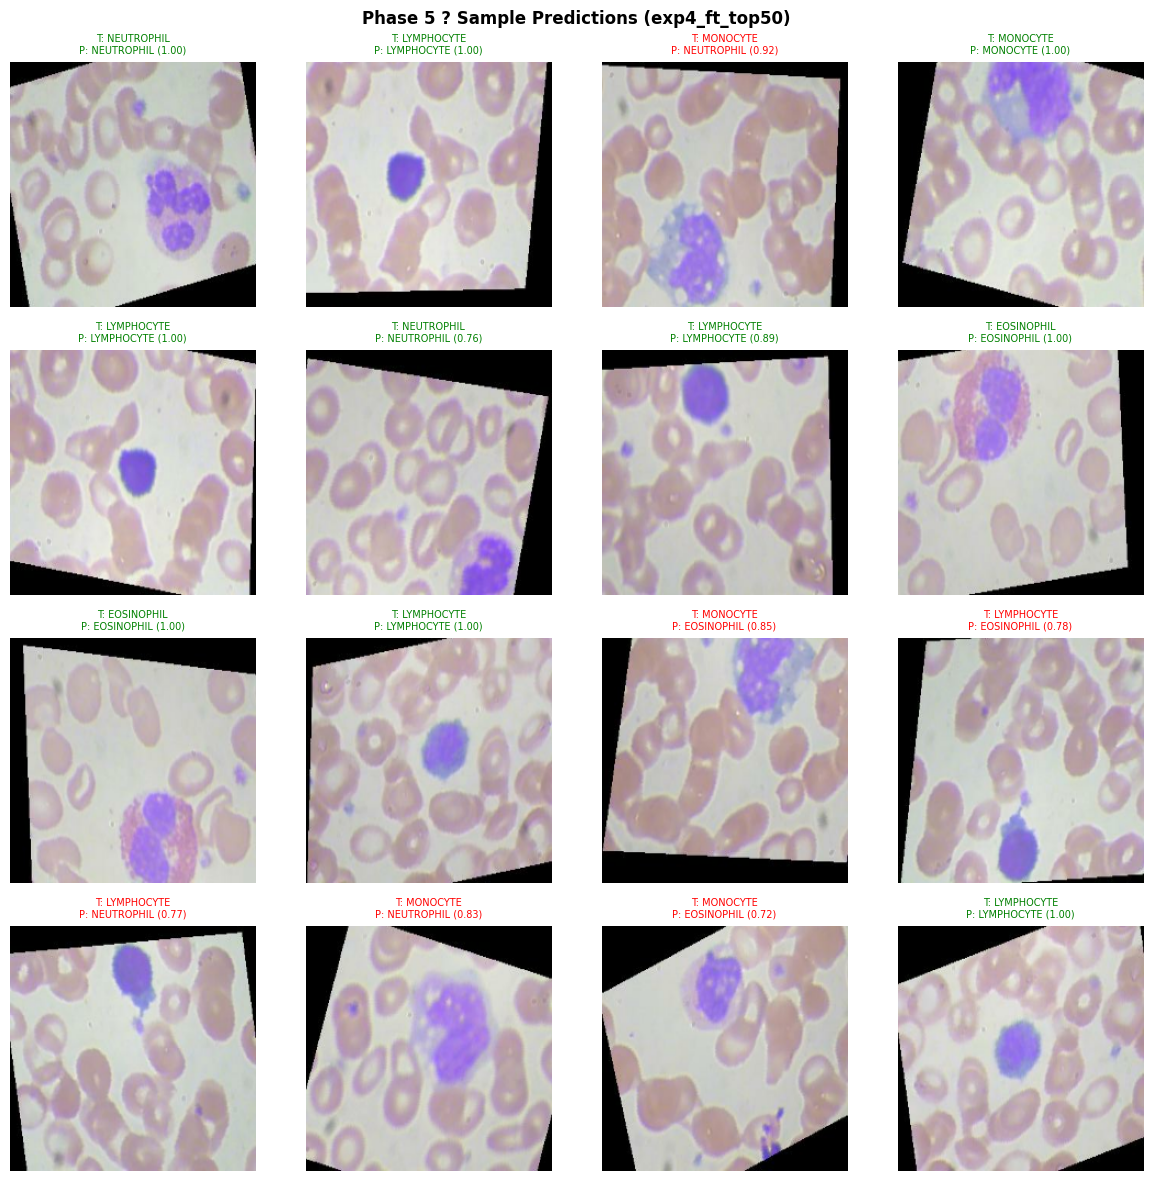

Saved: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/reports/figures/phase5_04_sample_predictions.png


In [22]:
# Show sample predictions from the best overall model
best_model = models[best_s2]

# Collect a batch of test images (un-preprocessed for display)
raw_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred', label_mode='categorical',
    class_names=CLASSES, image_size=IMG_SIZE,
    batch_size=32, shuffle=True, seed=SEED
)

raw_imgs, raw_labels = next(iter(raw_ds))
# Preprocess for prediction
proc_imgs = mobilenet_preprocess(tf.cast(raw_imgs, tf.float32))
preds = best_model.predict(proc_imgs, verbose=0)
pred_cls  = np.argmax(preds, axis=1)
true_cls  = np.argmax(raw_labels.numpy(), axis=1)

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle(f'Phase 5 ? Sample Predictions ({best_s2})', fontsize=12, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx >= n_show:
        ax.set_visible(False)
        continue
    img_np = raw_imgs[idx].numpy().astype('uint8')
    t = true_cls[idx]
    p = pred_cls[idx]
    conf = preds[idx][p]
    correct = (t == p)
    ax.imshow(img_np)
    ax.axis('off')
    color = 'green' if correct else 'red'
    ax.set_title(
        f'T: {CLASSES[t]}\nP: {CLASSES[p]} ({conf:.2f})',
        fontsize=7, color=color
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
save_path = FIGS_DIR / 'phase5_04_sample_predictions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path)

## 8. Cross-Phase Comparison

Compare test accuracy across all three phases to quantify the gain from transfer learning.


=== Cross-Phase Test Accuracy ===
Phase 2 Custom CNN                   0.6998  ???????????????????????????
Phase 3 Improved CNN                 0.7238  ????????????????????????????
MobileNetV2 Stage 1 (p03)            0.5569  ??????????????????????
MobileNetV2 Stage 2 (p50)            0.7467  ?????????????????????????????


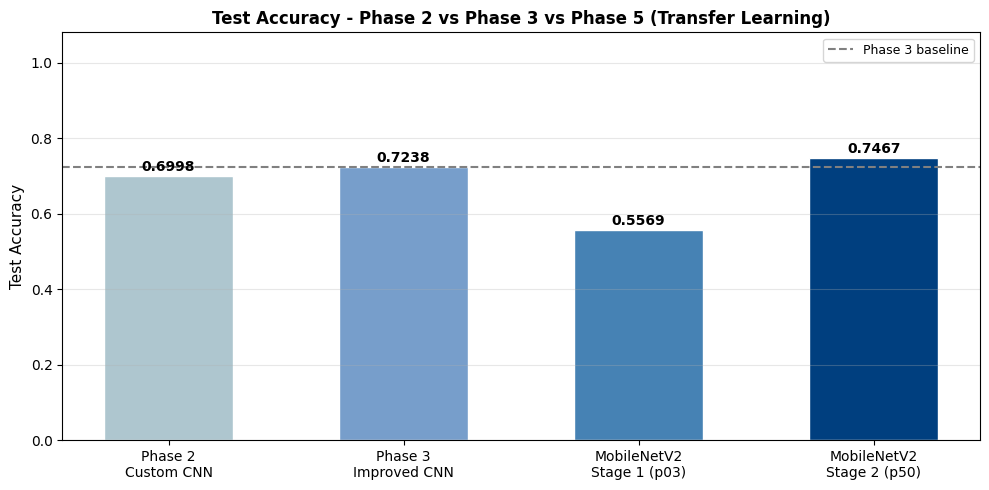

Saved: /mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML/reports/figures/phase5_05_phase_comparison.png


In [24]:
phase_names  = ['Phase 2\nCustom CNN', 'Phase 3\nImproved CNN',
                f'MobileNetV2\nStage 1 ({best_s1[-3:]})',
                f'MobileNetV2\nStage 2 ({best_s2[-3:]})']
phase_accs   = [PHASE2_TEST_ACC, PHASE3_TEST_ACC, acc_s1, acc_s2]
phase_colors = ['#aec6cf', '#779ecb', '#4682b4', '#003f7f']

print('\n=== Cross-Phase Test Accuracy ===')
for n, a in zip(phase_names, phase_accs):
    bar = '?' * int(a * 40)
    print(f'{n.replace(chr(10), " "):35s}  {a:.4f}  {bar}')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(phase_names, phase_accs, color=phase_colors, edgecolor='white', width=0.55)
for bar, acc in zip(bars, phase_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(PHASE3_TEST_ACC, color='gray', ls='--', lw=1.5, label='Phase 3 baseline')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Test Accuracy - Phase 2 vs Phase 3 vs Phase 5 (Transfer Learning)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_path = FIGS_DIR / 'phase5_05_phase_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path)